# Dependencies

In [16]:
!pip install datasets evaluate clean-text

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.9 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171033 sha256=a9432a2570679dae5e5c99049c759aef779308120c31bf300bf0015bcd74bdf7
  Stored in directory: /root/.cache/pip/wheels/bd/22/e5/b69726d5e1a19795ecd3b3e7464b16c0f1d019aa94ff1c8578
Successfully built emoji


In [21]:
pip install --upgrade clean-text

# Libraries

In [22]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import (
    XLNetTokenizer,
    XLNetForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random

# Preprocessing Data

In [23]:
data_train = pd.read_csv('emotions_data/emotion-labels-train.csv')
data_test = pd.read_csv('emotions_data/emotion-labels-test.csv')
data_val = pd.read_csv('emotions_data/emotion-labels-val.csv')

In [24]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [25]:
# Concat to clean all in one-go
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [26]:
# Remove Emoji
data['text_clean'] = data['text'].apply(lambda x: clean(x, no_emoji=True))
# Remove Punctuations
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub('@[^s]+', '', x))
# Inspect Data
data

TypeError: clean() got an unexpected keyword argument 'no_emoji'

In [30]:
import emoji
# Remove Emoji
data['text_clean'] = data['text'].apply(lambda x: emoji.replace_emoji(x, ''))
# Remove Punctuations
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub('@[^s]+', '', x))
# Lowercase
data['text_clean'] = data['text_clean'].apply(lambda x: x.lower())
# Inspect Data
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing slem. amazing!! face...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game #cheer #f...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,"so much, gloria! you're so sweet, and thoughtf..."
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"today i reached 1000 subscribers on yt!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,st day of fall. let's make some awesome #autum...
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#bridgetjonesbaby is the best thing i've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing slem. amazing!! face...
9,@IndyMN I thought the holidays could not get a...,joy,"s could not get any more cheerful, and then i ..."


<Axes: xlabel='label'>

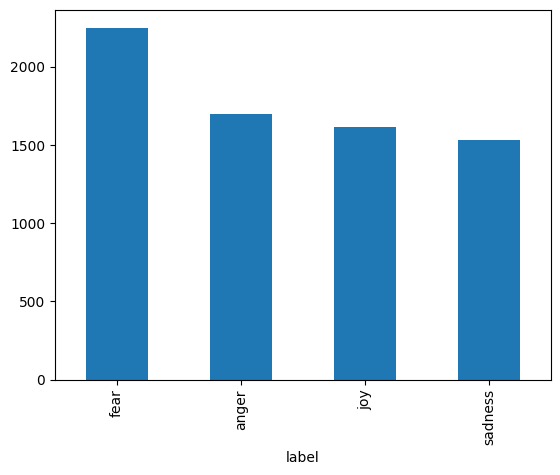

In [32]:
data['label'].value_counts().plot(kind='bar')

<ipython-input-33-45f7317d3214>:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

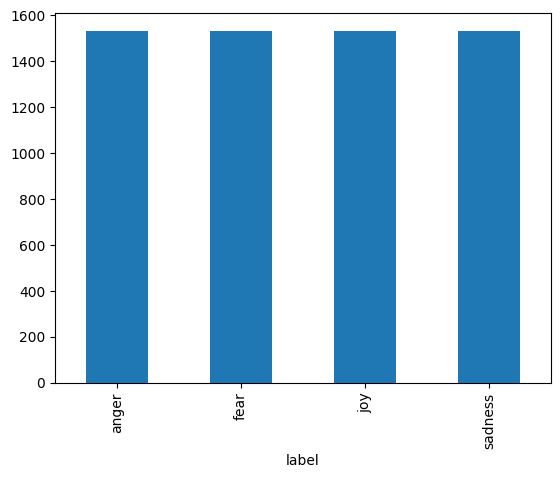

In [33]:
# Ensure they have same row amount
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))
data['label'].value_counts().plot(kind='bar')

In [38]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])
NUM_LABELS = 4

train, test = train_test_split(data, train_size=0.8, random_state=42)
train, val = train_test_split(train, train_size=0.9, random_state=42)

print(len(train), len(test), len(val))

4414 1227 491


In [40]:
train_df = pd.DataFrame({
    'label': train.label_int.values,
    'text': train.text_clean.values
})

test_df = pd.DataFrame({
    'label': test.label_int.values,
    'text': test.text_clean.values
})

train_df.head(3)

,label,text
0,3,who need #beats ? #instrumentals #serious #art...
1,1,can't believe how nervous i feel tonight...who...
2,0,i think i must scare my coworkers when i'm eat...


In [41]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)
dataset_dict = datasets.DatasetDict({
    'train': train_df,
    'test': test_df
})
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

# Create Embeddings

In [42]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length",
                     truncation=True, max_length=128)

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [43]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [45]:
print(tokenized_datasets['train']['text'][0])

who need #beats ? #instrumentals #serious #artists #only 


In [47]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 61, 214, 17, 7967, 11699, 23, 17, 82, 17, 7967, 4796, 6380, 18898, 23, 17, 7967, 18968, 17, 7967, 3432, 2309, 17, 7967, 6632, 4, 3]


# Test fine tuning with subset

In [48]:
train_subset = tokenized_datasets['train'].shuffle(seed=42).select(range(100))
test_subset = tokenized_datasets['test'].shuffle(seed=42).select(range(100))

In [51]:
model = XLNetForSequenceClassification.from_pretrained(
    "xlnet-base-cased", num_labels=NUM_LABELS,
    id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'})

pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [52]:
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  return metric.compute(predictions=predictions, references=labels)

In [53]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    eval_strategy='epoch',
    num_train_epochs=3
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=test_subset,
    compute_metrics=compute_metrics
)

In [54]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mahkotasteam (mahkotasteam-asia-pacific-university-of-technology-innov) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.431514,0.220000
2,No log,1.421463,0.250000
3,No log,1.435419,0.250000


TrainOutput(global_step=39, training_loss=1.3676200279822717, metrics={'train_runtime': 100.6988, 'train_samples_per_second': 2.979, 'train_steps_per_second': 0.387, 'total_flos': 21366375321600.0, 'train_loss': 1.3676200279822717, 'epoch': 3.0})

# Evaluate Model

In [55]:
trainer.evaluate()

{'eval_loss': 1.4354194402694702,
 'eval_accuracy': 0.25,
 'eval_runtime': 1.5722,
 'eval_samples_per_second': 63.606,
 'eval_steps_per_second': 8.269,
 'epoch': 3.0}

In [56]:
model.save_pretrained('fine_tuned_model')

In [57]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained('fine_tuned_model')
clf = pipeline("text-classification", model=fine_tuned_model, tokenizer=tokenizer)

Device set to use cuda:0


In [62]:
rand_int = random.randint(0, len(test_subset))
print(test_subset[rand_int]['text'])

say the words radical islamic terrorist, will that somehow make the terror groups drop their weapons?


In [63]:
answer = clf(test_subset[rand_int]['text'], top_k=None)
print(answer)

[{'label': 'joy', 'score': 0.2878301739692688}, {'label': 'anger', 'score': 0.2677665948867798}, {'label': 'sadness', 'score': 0.23432837426662445}, {'label': 'fear', 'score': 0.21007485687732697}]


# Fine Tune with full dataset

In [64]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [65]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    eval_strategy='epoch',
    num_train_epochs=3
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    compute_metrics=compute_metrics
)

In [66]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.082800,0.671431,0.753871
2,0.538500,0.588597,0.806846
3,0.382700,0.635918,0.812551


TrainOutput(global_step=1656, training_loss=0.6368082617791955, metrics={'train_runtime': 485.4251, 'train_samples_per_second': 27.279, 'train_steps_per_second': 3.411, 'total_flos': 943111806695424.0, 'train_loss': 0.6368082617791955, 'epoch': 3.0})

# Evaluate

In [67]:
trainer.evaluate()

{'eval_loss': 0.6359182000160217,
 'eval_accuracy': 0.8125509372453138,
 'eval_runtime': 12.0924,
 'eval_samples_per_second': 101.469,
 'eval_steps_per_second': 12.735,
 'epoch': 3.0}

In [68]:
model.save_pretrained('full_dataset_fine_tune_model')

In [70]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained('full_dataset_fine_tune_model')
clf = pipeline("text-classification", model=fine_tuned_model, tokenizer=tokenizer)

Device set to use cuda:0


In [71]:
rand_int = random.randint(0, len(test_subset))
print(test_subset[rand_int]['text'])

the majority of my clients have family/ partner/ day job/ life and write their beautiful books.  #gratitude #hardwork


In [72]:
answer = clf(test_subset[rand_int]['text'], top_k=None)
print(answer)

[{'label': 'joy', 'score': 0.9875401854515076}, {'label': 'anger', 'score': 0.006398863159120083}, {'label': 'sadness', 'score': 0.003571033477783203}, {'label': 'fear', 'score': 0.0024899146519601345}]


# Save model to local

In [73]:
!zip -r fine_tuned_model.zip full_dataset_fine_tune_model
from google.colab import files
files.download('fine_tuned_model.zip')

  adding: full_dataset_fine_tune_model/ (stored 0%)
  adding: full_dataset_fine_tune_model/model.safetensors (deflated 7%)
  adding: full_dataset_fine_tune_model/config.json (deflated 54%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
eval_results = trainer.evaluate()

# Create a DataFrame from the evaluation results
eval_df = pd.DataFrame([eval_results])

# Save the DataFrame to a CSV file
eval_df.to_csv('full_dataset_fine_tuned_model_evaluation.csv', index=False)

# Download the CSV file
files.download('full_dataset_fine_tuned_model_evaluation.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>